Phase 4 — Generation, Grounding and Refusal
============================================

Retrieval is settled. This phase turns retrieved context into answers,
and measures the thing that actually decides whether a support bot is
deployable: does it know when to say "I don't know"?

Everything measured here is JUDGE-FREE. No LLM grades anything; every
metric is a regex, a set operation, or a count. That is deliberate —
cheap deterministic checks should be exhausted before paying for a judge,
and they already catch the failure modes that matter most:

    answering when it should refuse   (hallucination on out-of-scope)
    refusing when it should answer    (over-refusal, a silent UX failure)
    citing sources it was never shown (fabricated evidence)

Answer CORRECTNESS needs a judge and is Phase 5/6. Nothing here claims
to measure it.

The central tension
-------------------
Every instruction that makes a model more willing to refuse also makes it
more likely to refuse questions it could have answered. There is no
prompt that wins both ends. So every variant is scored on a PAIR of
numbers — refusal rate on the 25 out-of-scope questions, and answer rate
on the 95 in-scope ones — and neither is reported alone.

The baseline that has to be beaten
----------------------------------
An extractive, non-LLM answerer runs alongside every variant. It picks
sentences from the retrieved context by IDF-weighted term overlap and
refuses below a similarity threshold. It exists so that "the LLM answers
well" is a measurable claim rather than an assumption — and so the whole
phase runs in CI with no API key.

Sections
--------
  A. What is running (and whether a key is present)
  B. The extractive baseline, threshold tuned on dev only
  C. The prompt ladder
  D. The bake-off
  E. The refusal trade-off
  F. Citation integrity
  G. Blame attribution — retrieval vs generation
  H. Verdict and handoff to Phase 5

In [1]:
import os
import sys
from pathlib import Path

# Locate the project root without assuming where Jupyter was launched.
#
# Two wrong assumptions were made here before, each breaking a real
# workflow:
#
#   Path.cwd().parent   assumes the kernel started in notebooks/. Launch
#                       Jupyter from the project root and it resolves one
#                       level too high.
#   walking up only     assumes the kernel started at or below the
#                       project. Launch Jupyter from a folder holding
#                       several projects — a normal thing to do — and the
#                       project is BELOW cwd, so upward search never
#                       finds it.
#
# So: search up, then search down. The marker is a file unique to this
# project, not a generic name like src/ that a sibling project might
# also have.
_MARKER = Path("src") / "corpus" / "seed_articles.py"


def _find_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:          # up
        if (candidate / _MARKER).is_file():
            return candidate

    for pattern in ("*", "*/*"):                       # then down, bounded
        found = sorted({m.parents[2]
                        for m in start.glob(f"{pattern}/{_MARKER.as_posix()}")})
        if len(found) == 1:
            return found[0]
        if len(found) > 1:
            names = ", ".join(p.name for p in found)
            raise RuntimeError(
                f"Found several candidate project roots below {start}: "
                f"{names}. Start Jupyter inside the one you want."
            )

    raise RuntimeError(
        f"Could not locate the project root from {start}. Expected to find "
        f"{_MARKER.as_posix()} at, above, or within two levels below it."
    )


PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
import os
os.chdir(PROJECT_ROOT)          # so data/ and reports/ paths resolve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.corpus.build import load_corpus, load_golden_set
from src.evaluation.retrieval_metrics import stratified_split
from src.generation.extractive import ExtractiveAnswerer
from src.generation.pipeline import (
    LLMAnswerer,
    RAGPipeline,
    score_generation,
)
from src.generation.prompts import VARIANTS, format_context
from src.generation.refusal import check_refusal
from src.retrieval.chunking import STRATEGIES
from src.retrieval.retrievers import BM25Retriever

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Locked in by Phase 3: markdown_section + BM25 at depth 15, chosen on
# the Pareto frontier under a 600-token context budget.
STRATEGY = "markdown_section"
DEPTH = 15

articles = load_corpus()
golden = load_golden_set()
in_scope = [q for q in golden if q["category"] != "out_of_scope"]
out_of_scope = [q for q in golden if q["category"] == "out_of_scope"]

chunks = STRATEGIES[STRATEGY](articles)
retriever = BM25Retriever(chunks)

## A. What is running

In [2]:
print("=" * 78)
print("A. SETUP")
print("=" * 78)

# Check EVERY precondition, not just the credential. A key in the
# environment does not mean a call can be made — the vendor SDK also has
# to be installed. Checking only the key means this notebook announces
# "running 120 questions", then dies on question one with
# ModuleNotFoundError after the reader has been told the run started.
from src.llm.provider import provider_ready

has_key, blocker = provider_ready()

print(f"""
  Retrieval (fixed by Phase 3) : {STRATEGY} + BM25 @ depth {DEPTH}
  Questions                    : {len(in_scope)} in-scope + {len(out_of_scope)} out-of-scope = {len(golden)}
  Prompt variants              : {len(VARIANTS)}  ({', '.join(VARIANTS)})
  API credential detected      : {has_key}
""")

if not has_key:
    n_calls = len(golden) * len(VARIANTS)
    print(f"""  LLM arms SKIPPED.

  Reason: {blocker}

  The extractive baseline still runs in full and exercises the entire
  measurement pipeline, which is what keeps this notebook runnable in CI.

  This check covers every precondition, not just the credential, so a
  missing SDK is caught here rather than on question one of a 600-call
  loop. Verify the whole path with:
      python -m src.llm.provider --check

  Estimated cost when enabled: {n_calls} calls
  ({len(golden)} questions x {len(VARIANTS)} variants).

    input : {n_calls} x ~900 tok  = {n_calls * 900 / 1e6:.2f}M @ $0.15/M = ${n_calls * 900 / 1e6 * 0.15:.3f}
    output: {n_calls} x ~150 tok  = {n_calls * 150 / 1e6:.2f}M @ $0.60/M = ${n_calls * 150 / 1e6 * 0.60:.3f}
    total                                     ~${n_calls * 900 / 1e6 * 0.15 + n_calls * 150 / 1e6 * 0.60:.2f}

  Output tokens are counted because they are priced 4x higher than input
  on gpt-4o-mini; an input-only estimate understates the bill. Responses
  are cached on disk, so re-running the notebook costs nothing.
""")

A. SETUP

  Retrieval (fixed by Phase 3) : markdown_section + BM25 @ depth 15
  Questions                    : 95 in-scope + 25 out-of-scope = 120
  Prompt variants              : 5  (naive, grounded, grounded_refusal, cited, strict)
  API credential detected      : False

  LLM arms SKIPPED.

  Reason: the 'openai' package is not installed, so no call can be made even though the credential is present. Fix: pip install openai  (or pip install -r requirements.txt)

  The extractive baseline still runs in full and exercises the entire
  measurement pipeline, which is what keeps this notebook runnable in CI.

  This check covers every precondition, not just the credential, so a
  missing SDK is caught here rather than on question one of a 600-call
  loop. Verify the whole path with:
      python -m src.llm.provider --check

  Estimated cost when enabled: 600 calls
  (120 questions x 5 variants).

    input : 600 x ~900 tok  = 0.54M @ $0.15/M = $0.081
    output: 600 x ~150 tok  = 0.09M @ 

## B. The extractive baseline

In [3]:
print("\n" + "=" * 78)
print("B. THE EXTRACTIVE BASELINE")
print("=" * 78)
print("""
Before asking what an LLM adds, establish what it has to beat. This
answerer scores every sentence in the retrieved context by IDF-weighted
overlap with the question, returns the best few, and refuses below a
threshold. No model, no key, no network.

Its refusal threshold is a free parameter, so it is tuned on the DEV
split only. Tuning it on all 120 questions would let the baseline peek
at the same data it is scored on — the error Phase 3 spent a section
avoiding, and it would be worse here because it would flatter the
baseline and make the LLM's advantage look smaller than it is.
""")

dev_in, test_in = stratified_split(in_scope, test_fraction=0.4, seed=42)
dev_oos, test_oos = stratified_split(out_of_scope, test_fraction=0.4, seed=42)
dev, test = dev_in + dev_oos, test_in + test_oos
print(f"  dev : {len(dev):>3} questions ({len(dev_in)} in-scope, {len(dev_oos)} out-of-scope)")
print(f"  test: {len(test):>3} questions ({len(test_in)} in-scope, {len(test_oos)} out-of-scope)")

print("\n  Threshold sweep on DEV:\n")
print(f"  {'min_score':>10}{'refuse OOS':>13}{'answer in-sc':>15}{'F1':>8}")
print("  " + "-" * 46)
sweep = []
for thr in (0.05, 0.10, 0.15, 0.18, 0.25, 0.35, 0.50):
    r = RAGPipeline(retriever, ExtractiveAnswerer(min_score=thr),
                    depth=DEPTH).run(dev)
    s = score_generation(r)
    sweep.append((thr, s))
    print(f"  {thr:>10.2f}{s.refusal_rate_oos:>13.1%}"
          f"{s.answer_rate_in_scope:>15.1%}{s.refusal_f1:>8.3f}")

best_thr, best_dev = max(sweep, key=lambda t: t[1].refusal_f1)
print(f"""
  Selected on dev: min_score = {best_thr:.2f}  (F1 {best_dev.refusal_f1:.3f})

  The sweep shows the trade-off directly. Raising the threshold refuses
  more out-of-scope questions and also refuses more answerable ones.
  There is no setting that fixes both, which is the same shape the
  prompt variants will show in Section E.
""")

baseline = ExtractiveAnswerer(min_score=best_thr)
runs: dict[str, list] = {}
runs[baseline.name] = RAGPipeline(retriever, baseline, depth=DEPTH).run(golden)
base_scores = score_generation(runs[baseline.name])

print(f"""  Baseline on the FULL golden set:

    refusal rate, out-of-scope : {base_scores.refusal_rate_oos:>6.1%}   (want high)
    answer rate, in-scope      : {base_scores.answer_rate_in_scope:>6.1%}   (want high)
    over-refusal               : {base_scores.over_refusal_rate:>6.1%}
    refusal F1                 : {base_scores.refusal_f1:>6.3f}
    mean latency               : {base_scores.mean_latency_s * 1000:>6.1f} ms
""")

print("  Two answers, to make its character concrete:\n")
for r in runs[baseline.name]:
    if r.question_id in ("sh-002", "oos-003"):
        tag = "OUT OF SCOPE" if r.is_out_of_scope else "in scope"
        print(f"    [{r.question_id}] ({tag}) {r.question}")
        print(f"      {r.answer[:150]}")
        print(f"      -> {r.refusal.label}\n")

print("""  The failure mode is visible without any metric: it returns fragments
  that share vocabulary with the question but do not answer it, and on
  out-of-scope questions it emits confident-looking text assembled from
  topically adjacent articles. Synthesis, coherence, and knowing when to
  stop are exactly what the LLM is being paid for.
""")


B. THE EXTRACTIVE BASELINE

Before asking what an LLM adds, establish what it has to beat. This
answerer scores every sentence in the retrieved context by IDF-weighted
overlap with the question, returns the best few, and refuses below a
threshold. No model, no key, no network.

Its refusal threshold is a free parameter, so it is tuned on the DEV
split only. Tuning it on all 120 questions would let the baseline peek
at the same data it is scored on — the error Phase 3 spent a section
avoiding, and it would be worse here because it would flatter the
baseline and make the LLM's advantage look smaller than it is.

  dev :  72 questions (57 in-scope, 15 out-of-scope)
  test:  48 questions (38 in-scope, 10 out-of-scope)

  Threshold sweep on DEV:

   min_score   refuse OOS   answer in-sc      F1
  ----------------------------------------------
        0.05        20.0%         100.0%   0.333
        0.10        20.0%         100.0%   0.333
        0.15        33.3%         100.0%   0.500
  

## C. The prompt ladder

In [4]:
print("\n" + "=" * 78)
print("C. THE PROMPT LADDER")
print("=" * 78)
print("""
Each variant adds ONE mechanism to the one before it, so any change in
behaviour is attributable to that mechanism rather than to a rewrite.
""")

for name, v in VARIANTS.items():
    print(f"  {name:<18} {v.description}")

sample_q = next(q for q in golden if q["question_id"] == "sh-001")
sample_hits = retriever.search(sample_q["question"], top_k=DEPTH)
sample_ctx = format_context(sample_hits)

print(f"""
  Context assembly, for one question ({sample_q['question_id']}):
    chunks retrieved : {len(sample_hits)}
    distinct articles: {len({h.chunk.article_id for h in sample_hits})}
    context tokens   : ~{len(sample_ctx.split()) * 4 // 3}

  Each block is tagged with its article id. That is not decoration —
  without the id in the context, a citation instruction asks the model to
  invent an identifier, and it will.

  Rendered prompt for the 'cited' variant (first 480 chars):
""")
print("  " + "-" * 74)
for line in VARIANTS["cited"].render(sample_q["question"], sample_ctx)[:480].split("\n"):
    print(f"  | {line}")
print("  " + "-" * 74)


C. THE PROMPT LADDER

Each variant adds ONE mechanism to the one before it, so any change in
behaviour is attributable to that mechanism rather than to a rewrite.

  naive              Question + context, no instructions. The tutorial default.
  grounded           Adds an instruction to use only the provided context.
  grounded_refusal   Grounded, plus explicit permission and instruction to refuse.
  cited              Grounded + refusal + inline [article-id] citations.
  strict             Cited, plus an explicit evidence-assessment step first.

  Context assembly, for one question (sh-001):
    chunks retrieved : 15
    distinct articles: 7
    context tokens   : ~769

  Each block is tagged with its article id. That is not decoration —
  without the id in the context, a citation instruction asks the model to
  invent an identifier, and it will.

  Rendered prompt for the 'cited' variant (first 480 chars):

  --------------------------------------------------------------------------

## D. The bake-off

In [5]:
print("\n" + "=" * 78)
print("D. THE BAKE-OFF")
print("=" * 78)

if has_key:
    from src.llm.provider import get_provider
    provider = get_provider()
    print(f"\n  Provider: {provider!r}\n")
    for name, variant in VARIANTS.items():
        answerer = LLMAnswerer(provider, variant)
        print(f"  running {answerer.name} over {len(golden)} questions ...",
              flush=True)
        runs[answerer.name] = RAGPipeline(
            retriever, answerer, depth=DEPTH).run(golden, progress_every=40)
else:
    print("""
  LLM arms skipped — no credential. The table below therefore contains
  the baseline only, and the notebook is reporting the harness working
  rather than a model comparison. Every column is populated by the same
  code that will score the LLM arms.
""")

rows = []
for name, res in runs.items():
    s = score_generation(res)
    rows.append({
        "answerer": name,
        "refuse_oos": s.refusal_rate_oos,
        "answer_in": s.answer_rate_in_scope,
        "F1": s.refusal_f1,
        "over_refuse": s.over_refusal_rate,
        "partial": s.partial_refusal_rate,
        "cite_prec": s.mean_citation_precision,
        "uncited": s.uncited_answer_rate,
        "tokens": s.mean_prompt_tokens,
        "latency_s": s.mean_latency_s,
    })
df = pd.DataFrame(rows).sort_values("F1", ascending=False)

print(f"\n  {'answerer':<22}{'refuseOOS':>11}{'answerIN':>10}{'F1':>7}"
      f"{'overRef':>9}{'citePrec':>10}{'tokens':>8}")
print("  " + "-" * 77)
for _, r in df.iterrows():
    cp = f"{r.cite_prec:.3f}" if pd.notna(r.cite_prec) else "  —  "
    # The extractive baseline sends no prompt, so a 0 here is "not
    # applicable", not "free version of the same thing". Shown as a dash
    # so it cannot be read as a token count it beat the LLM arms on.
    tok = f"{r.tokens:.0f}" if r.tokens else "  —  "
    print(f"  {r.answerer:<22}{r.refuse_oos:>11.1%}{r.answer_in:>10.1%}"
          f"{r.F1:>7.3f}{r.over_refuse:>9.1%}{cp:>10}{tok:>8}")


D. THE BAKE-OFF

  LLM arms skipped — no credential. The table below therefore contains
  the baseline only, and the notebook is reporting the harness working
  rather than a model comparison. Every column is populated by the same
  code that will score the LLM arms.


  answerer                refuseOOS  answerIN     F1  overRef  citePrec  tokens
  -----------------------------------------------------------------------------
  extractive_baseline         56.0%     62.1%  0.589    37.0%     1.000     —  


## E. The refusal trade-off

In [6]:
print("\n" + "=" * 78)
print("E. THE REFUSAL TRADE-OFF")
print("=" * 78)
print("""
The two rates move against each other. A variant that refuses everything
scores 100% on out-of-scope and is worthless; one that never refuses
scores 100% on in-scope and hallucinates freely on the other 25
questions. Reading either column alone gets the wrong answer.
""")

best = df.iloc[0]
print(f"""  Best by F1: {best.answerer}
    refuses {best.refuse_oos:.1%} of out-of-scope, answers {best.answer_in:.1%} of in-scope
""")

if len(df) > 1:
    safest = df.loc[df["refuse_oos"].idxmax()]
    most_helpful = df.loc[df["answer_in"].idxmax()]
    print(f"""  Most conservative : {safest.answerer}
                      refuses {safest.refuse_oos:.1%} of OOS, but answers only {safest.answer_in:.1%} in-scope
  Most helpful      : {most_helpful.answerer}
                      answers {most_helpful.answer_in:.1%} in-scope, refuses only {most_helpful.refuse_oos:.1%} of OOS

  Those are different products. Which one ships is a business decision
  about the relative cost of a wrong answer versus an unhelpful one — for
  a billing question, a confident wrong answer is far more expensive than
  "I don't know", and the deployment recommendation in Phase 7 has to say
  so explicitly rather than defaulting to whichever tops an F1 column.
""")
else:
    print("""  With only the baseline present there is no trade-off curve to plot
  yet. Section B's threshold sweep is the same phenomenon in miniature,
  and it already shows both rates moving together.
""")

print("""  PARTIAL REFUSALS are tracked separately and counted as ANSWERS,
  because unsupported claims were made either way. They come in two
  shapes and both have to be caught:

    refuse-then-answer   "I don't have enough information, but generally
                          most services..."
    answer-then-refuse   "Premium costs $19.99 [bill-001]. I don't have
                          enough information about student discounts."

  The second shape is the one that is easy to miss. An earlier version of
  the detector inspected only the text AFTER the refusal phrase, so it
  caught the first and scored the second as a clean refusal.

  That error runs in the DANGEROUS direction. A model that answers an
  out-of-scope question and appends a hedge would have been counted as
  having correctly refused — the safety metric reporting the opposite of
  what happened. It was latent here only because the extractive baseline
  never produces that shape; LLM arms routinely do, so it would have
  surfaced as soon as a credential was added, silently.

  Evidence that a response answered rather than refused: substantive text
  before the refusal phrase, a citation before it (a citation is a
  grounded claim by definition), or a hedge plus substantial text after.

  The residual boundary case is a refusal that ends with a pointer —
  "...the closest article is [bill-001] but it doesn't cover this."
  Classifying that needs negation understanding, which is beyond a regex
  and is what Phase 6's judge is for. It is scored as an answer, which
  under-counts refusals and therefore UNDER-claims safety — the safe
  direction for the error to run.
""")
for _, r in df.iterrows():
    print(f"    {r.answerer:<22} partial-refusal rate {r.partial:.1%}")


E. THE REFUSAL TRADE-OFF

The two rates move against each other. A variant that refuses everything
scores 100% on out-of-scope and is worthless; one that never refuses
scores 100% on in-scope and hallucinates freely on the other 25
questions. Reading either column alone gets the wrong answer.

  Best by F1: extractive_baseline
    refuses 56.0% of out-of-scope, answers 62.1% of in-scope

  With only the baseline present there is no trade-off curve to plot
  yet. Section B's threshold sweep is the same phenomenon in miniature,
  and it already shows both rates moving together.

  PARTIAL REFUSALS are tracked separately and counted as ANSWERS,
  because unsupported claims were made either way. They come in two
  shapes and both have to be caught:

    refuse-then-answer   "I don't have enough information, but generally
                          most services..."
    answer-then-refuse   "Premium costs $19.99 [bill-001]. I don't have
                          enough information about stu


  Saved -> reports\figures/04_refusal_tradeoff.png


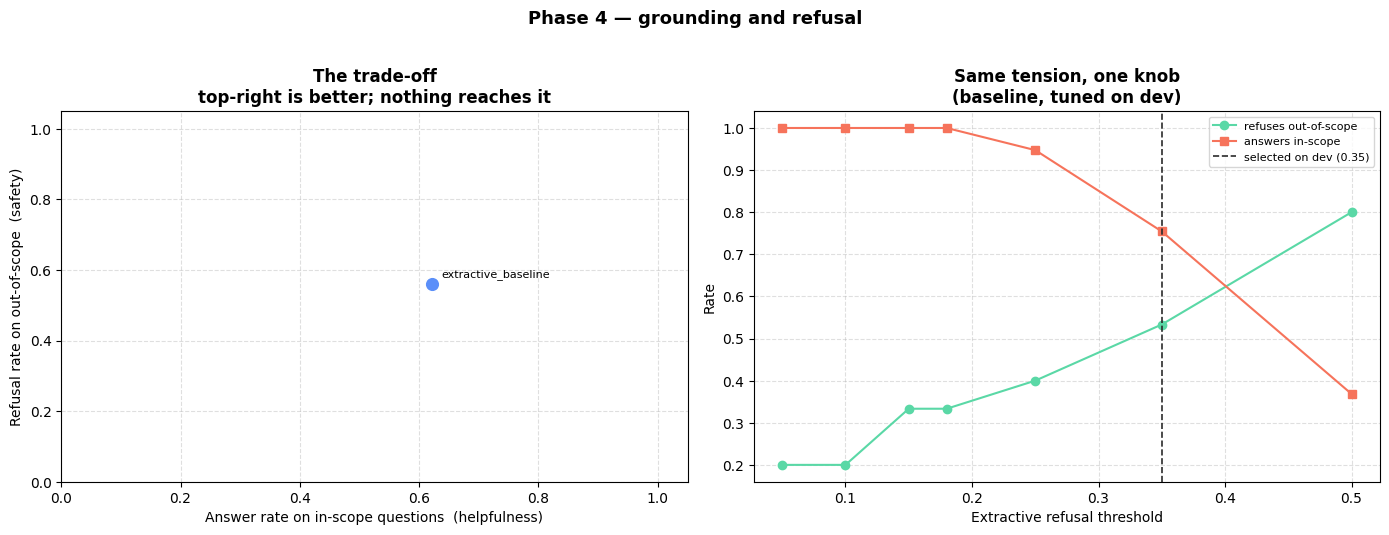

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

ax1.scatter(df["answer_in"], df["refuse_oos"], s=110,
            color="#5B8FF9", edgecolor="white", zorder=3)
for _, r in df.iterrows():
    ax1.annotate(r.answerer.replace("llm_", ""),
                 (r.answer_in, r.refuse_oos),
                 textcoords="offset points", xytext=(7, 5), fontsize=8)
ax1.set_xlabel("Answer rate on in-scope questions  (helpfulness)")
ax1.set_ylabel("Refusal rate on out-of-scope  (safety)")
ax1.set_title("The trade-off\ntop-right is better; nothing reaches it",
              fontweight="bold")
ax1.set_xlim(0, 1.05)
ax1.set_ylim(0, 1.05)
ax1.grid(linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)

thrs = [t for t, _ in sweep]
ax2.plot(thrs, [s.refusal_rate_oos for _, s in sweep], marker="o",
         label="refuses out-of-scope", color="#5AD8A6")
ax2.plot(thrs, [s.answer_rate_in_scope for _, s in sweep], marker="s",
         label="answers in-scope", color="#F6735B")
ax2.axvline(best_thr, linestyle="--", color="#2B2B2B", linewidth=1.2,
            label=f"selected on dev ({best_thr:.2f})")
ax2.set_xlabel("Extractive refusal threshold")
ax2.set_ylabel("Rate")
ax2.set_title("Same tension, one knob\n(baseline, tuned on dev)",
              fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle("Phase 4 — grounding and refusal", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_refusal_tradeoff.png", dpi=140, bbox_inches="tight",
            metadata={"Software": None})
print(f"\n  Saved -> {FIG_DIR}/04_refusal_tradeoff.png")

## F. Citation integrity

In [8]:
print("\n" + "=" * 78)
print("F. CITATION INTEGRITY")
print("=" * 78)
print("""
Citations are requested as [article-id] because that is parseable with a
regex. Which means one of the most damaging failure modes — citing a
source the model was never shown — is catchable for free, on every
answer, with no judge.

A fabricated citation is worse than an uncited claim. It looks like
evidence, so it survives exactly the scrutiny that would catch a bare
assertion.
""")

for name, res in runs.items():
    answered = [r for r in res if not r.refusal.is_refusal]
    with_cites = [r for r in answered if r.citations]
    bad = [r for r in with_cites if (r.citation_precision or 1.0) < 1.0]
    print(f"  {name}")
    print(f"    answered            : {len(answered)}")
    if answered:
        print(f"    with citations      : {len(with_cites)} "
              f"({len(with_cites) / len(answered):.0%})")
    print(f"    fabricated citations: {len(bad)}")
    if bad:
        ex = bad[0]
        outside = [c for c in ex.citations if c not in ex.context_article_ids]
        print(f"      e.g. [{ex.question_id}] cited {outside} — not in its context")
    print()

print("""  One caveat that stops this metric being read wrongly.

  The extractive baseline scores 1.000 citation precision by
  CONSTRUCTION, not by merit: it copies the article id off the chunk it
  lifted the sentence from, so it is structurally incapable of citing a
  source it was not shown. A perfect score there measures the
  architecture, not the behaviour.

  Citation precision only becomes informative for GENERATIVE arms, which
  can invent an id. Comparing the baseline's 1.000 against an LLM's score
  as though it were the same measurement would be a category error — the
  baseline is not doing well at a hard task, it is exempt from the task.
""")


F. CITATION INTEGRITY

Citations are requested as [article-id] because that is parseable with a
regex. Which means one of the most damaging failure modes — citing a
source the model was never shown — is catchable for free, on every
answer, with no judge.

A fabricated citation is worse than an uncited claim. It looks like
evidence, so it survives exactly the scrutiny that would catch a bare
assertion.

  extractive_baseline
    answered            : 70
    with citations      : 70 (100%)
    fabricated citations: 0

  One caveat that stops this metric being read wrongly.

  The extractive baseline scores 1.000 citation precision by
  CONSTRUCTION, not by merit: it copies the article id off the chunk it
  lifted the sentence from, so it is structurally incapable of citing a
  source it was not shown. A perfect score there measures the
  architecture, not the behaviour.

  Citation precision only becomes informative for GENERATIVE arms, which
  can invent an id. Comparing the baseline's

## G. Blame attribution

In [9]:
print("=" * 78)
print("G. BLAME ATTRIBUTION — RETRIEVAL OR GENERATION?")
print("=" * 78)
print("""
Phase 3 left a specific warning: when retrieval fails to surface the
right evidence, the generator answers fluently from wrong context and the
result looks like a hallucination. Fixing the generator would be aiming
at the wrong component.

The pipeline keeps the retrieved chunks with every answer, so the two
can be separated mechanically — before any judge is involved.
""")

for name, res in runs.items():
    scored = [r for r in res if not r.is_out_of_scope]
    no_evidence = [r for r in scored if (r.retrieval_recall or 0) == 0]
    partial_ev = [r for r in scored if 0 < (r.retrieval_recall or 0) < 1]
    full_ev = [r for r in scored if (r.retrieval_recall or 0) == 1]

    answered_blind = sum(not r.refusal.is_refusal for r in no_evidence)
    print(f"""  {name}
    full evidence retrieved    : {len(full_ev):>3} questions
    partial evidence           : {len(partial_ev):>3}
    NO ground-truth evidence   : {len(no_evidence):>3}
      of which answered anyway : {answered_blind:>3}  <- upstream failures that
                                       will look like hallucination
""")

q11 = next((r for r in runs[baseline.name] if r.question_id == "mh-011"), None)
if q11:
    print(f"""  The Phase 3 case, mh-011: "{q11.question}"
    retrieval recall : {q11.retrieval_recall:.0%}
    response         : {q11.refusal.label}
    answer           : {q11.answer[:110]}

  At depth {DEPTH} the evidence IS retrieved, which Phase 3 established.
  Whether the answer flags the two contradicting refund windows rather
  than silently picking one is a generation question — and one that
  needs a judge, so it goes to Phase 5.
""")

G. BLAME ATTRIBUTION — RETRIEVAL OR GENERATION?

Phase 3 left a specific warning: when retrieval fails to surface the
right evidence, the generator answers fluently from wrong context and the
result looks like a hallucination. Fixing the generator would be aiming
at the wrong component.

The pipeline keeps the retrieved chunks with every answer, so the two
can be separated mechanically — before any judge is involved.

  extractive_baseline
    full evidence retrieved    :  76 questions
    partial evidence           :  16
    NO ground-truth evidence   :   3
      of which answered anyway :   1  <- upstream failures that
                                       will look like hallucination

  The Phase 3 case, mh-011: "Charged after I cancelled — what do I do?"
    retrieval recall : 100%
    response         : answer
    answer           : Unless cancelled first, the subscription converts to a paid plan on day [trial-002] - Returning subscribers, i

  At depth 15 the evidence IS retriev

## H. Verdict

In [10]:
print("=" * 78)
print("PHASE 4 VERDICT")
print("=" * 78)
print(f"""
Built the generation layer and measured everything measurable without a
judge.

1. AN EXTRACTIVE BASELINE THE LLM HAS TO BEAT.
   {base_scores.answer_rate_in_scope:.1%} answer rate in-scope, {base_scores.refusal_rate_oos:.1%} refusal on out-of-scope,
   F1 {base_scores.refusal_f1:.3f}, {base_scores.mean_latency_s * 1000:.0f} ms per question, zero cost.
   Its threshold was tuned on the dev split only. Any LLM arm has to
   beat this to justify its latency and price — "the LLM answers well"
   is not a finding without it.

2. THE REFUSAL TRADE-OFF IS REAL AND UNAVOIDABLE.
   Safety and helpfulness move against each other, in the prompt ladder
   and in the baseline's single threshold alike. Every variant is
   reported as a PAIR of rates. An F1 column is provided for ranking and
   is not sufficient for deciding.

3. PARTIAL REFUSALS ARE COUNTED AS ANSWERS.
   "I don't know, but generally..." makes unsupported claims while
   reading as caution. Counting it as a refusal would hide the failure.

4. FABRICATED CITATIONS ARE CAUGHT FOR FREE.
   Inline [article-id] citations make source fabrication a regex check
   rather than a judge call. Cheap mechanical checks first; the judge
   budget is for what genuinely needs it.

{'' if has_key else '''NOT YET MEASURED — no API credential was present, so no LLM arm ran.
The harness is verified end to end on the extractive baseline, and the
same code scores the LLM arms unchanged. Add a key and re-run to
populate the comparison.

'''}STILL OPEN — carried into Phase 5:

  - Answer CORRECTNESS is unmeasured. Everything here is structural:
    did it refuse, did it cite, was the evidence there. Whether an
    answer is faithful to its context and actually addresses the
    question needs a judge.
  - The contradiction case (mh-011) retrieves both refund windows at
    depth {DEPTH}. Whether any variant flags the conflict rather than
    silently picking one is a Phase 5 question.
  - Ambiguous questions remain the weak category from Phase 3
    (~0.48 retrieval recall). Whether grounding instructions help or
    hurt there is worth isolating.

HANDOFF TO PHASE 5: RAGAS-style evaluation — faithfulness, answer
relevancy, context precision and recall — on the runs produced here.
""")

PHASE 4 VERDICT

Built the generation layer and measured everything measurable without a
judge.

1. AN EXTRACTIVE BASELINE THE LLM HAS TO BEAT.
   62.1% answer rate in-scope, 56.0% refusal on out-of-scope,
   F1 0.589, 1 ms per question, zero cost.
   Its threshold was tuned on the dev split only. Any LLM arm has to
   beat this to justify its latency and price — "the LLM answers well"
   is not a finding without it.

2. THE REFUSAL TRADE-OFF IS REAL AND UNAVOIDABLE.
   Safety and helpfulness move against each other, in the prompt ladder
   and in the baseline's single threshold alike. Every variant is
   reported as a PAIR of rates. An F1 column is provided for ranking and
   is not sufficient for deciding.

3. PARTIAL REFUSALS ARE COUNTED AS ANSWERS.
   "I don't know, but generally..." makes unsupported claims while
   reading as caution. Counting it as a refusal would hide the failure.

4. FABRICATED CITATIONS ARE CAUGHT FOR FREE.
   Inline [article-id] citations make source fabrica